<a href="https://colab.research.google.com/github/ajs-sw/2026_tues_bigdatacomputing_class/blob/main/20230579_%EC%95%88%EC%A0%95%EC%88%98_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  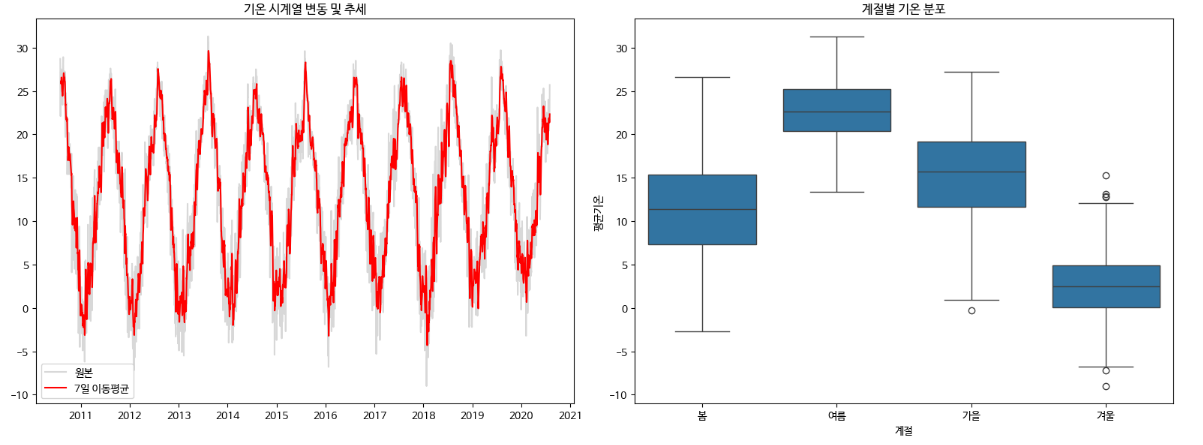

  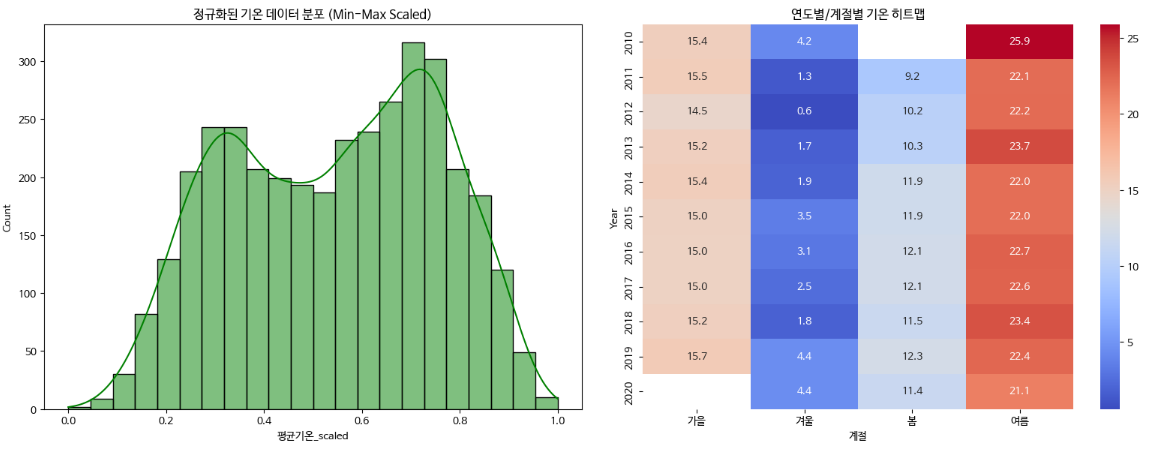



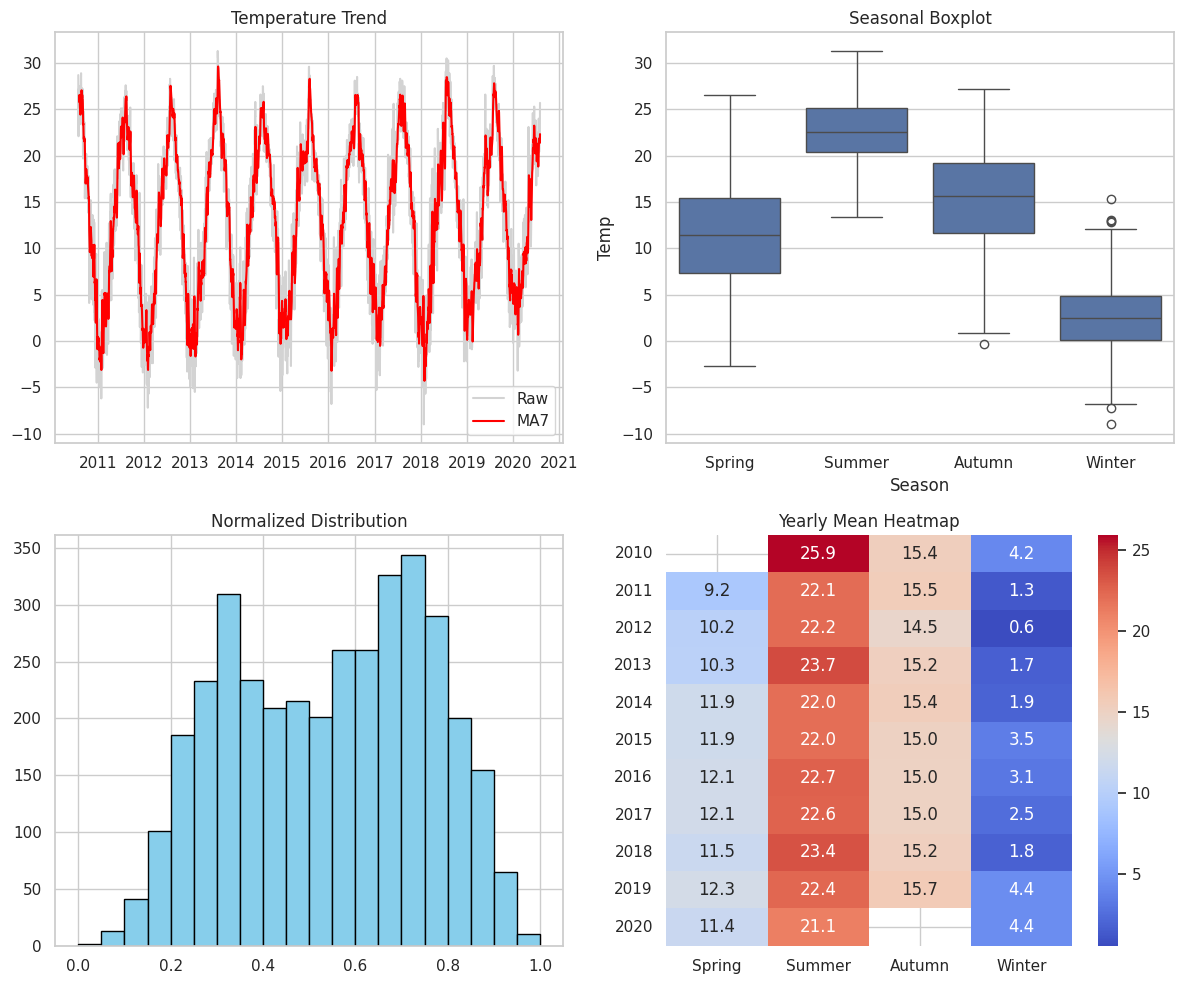

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    path = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    data = pd.read_csv(path, encoding='cp949')
    data.rename(columns={'일시': 'Date', '평균기온': 'Temp'}, inplace=True)
    data['Date'] = pd.to_datetime(data['Date'])

    temp_list = []
    for i in range(len(data)):
        if not pd.isna(data.loc[i, 'Temp']):
            val = data.iloc[i].copy()
            m = val['Date'].month
            if 3 <= m <= 5:
                val['Season'] = 'Spring'
            elif 6 <= m <= 8:
                val['Season'] = 'Summer'
            elif 9 <= m <= 11:
                val['Season'] = 'Autumn'
            else:
                val['Season'] = 'Winter'

            temp_list.append(val)
    df = pd.DataFrame(temp_list).reset_index(drop=True)
    ma_vals = [np.nan] * len(df)

    for i in range(6, len(df)):
        current_sum = 0
        for j in range(7):
            current_sum += df.loc[i-j, 'Temp']
        ma_vals[i] = current_sum / 7
    df['MA7'] = ma_vals

    low = df['Temp'].min()
    high = df['Temp'].max()
    df['Scaled'] = (df['Temp'] - low) / (high - low)
    s_list = ['Spring', 'Summer', 'Autumn', 'Winter']
    res = []

    for s in s_list:
        pick = df[df['Season'] == s]['Temp']
        res.append({
            'Season': s,
            'Count': len(pick),
            'Mean': pick.mean(),
            'Std': pick.std(),
            'Min': pick.min(),
            'Max': pick.max()
        })
    stats_df = pd.DataFrame(res).set_index('Season')

    df['Year'] = df['Date'].dt.year
    yr_list = sorted(df['Year'].unique())

    pivot = pd.DataFrame(index=yr_list, columns=s_list)
    for yr in yr_list:
        for se in s_list:
            target = df[(df['Year'] == yr) & (df['Season'] == se)]['Temp']
            if len(target) > 0:
                pivot.loc[yr, se] = target.mean()

    pivot = pivot.astype(float)
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(df['Date'], df['Temp'], color='lightgray', label='Raw')
    plt.plot(df['Date'], df['MA7'], color='red', label='MA7')
    plt.title('Temperature Trend')
    plt.legend()

    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, x='Season', y='Temp', order=s_list)
    plt.title('Seasonal Boxplot')

    plt.subplot(2, 2, 3)
    plt.hist(df['Scaled'], bins=20, color='skyblue', edgecolor='black')
    plt.title('Normalized Distribution')

    plt.subplot(2, 2, 4)
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')
    plt.title('Yearly Mean Heatmap')

    plt.tight_layout()
    plt.show()

    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        df.to_excel(writer, sheet_name='CleanData', index=False)
        stats_df.to_excel(writer, sheet_name='Stats')
        pivot.to_excel(writer, sheet_name='YearPivot')

if __name__ == "__main__":
    main()